In [1]:
import warnings; warnings.filterwarnings(action='ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pyupbit

In [34]:
sample = pyupbit.get_ohlcv("KRW-ETH", count=600)

sample['mom7'] = (sample['close'] - sample.shift(7)['close'])/sample.shift(7)['close']
sample['mom20'] = (sample['close'] - sample.shift(20)['close'])/sample.shift(20)['close']
sample['center'] = sample['close'].rolling(20).mean()
sample['upper'] = sample['center'] + 2.*sample['close'].rolling(2).std()
sample['lower'] = sample['center'] - 2.*sample['close'].rolling(2).std()
sample['percentB'] = (sample['close'] - sample['lower'])/(sample['upper'] - sample['lower'])
sample['reward'] = 1.+sample['close'].pct_change()
sample['total_reward'] = sample['reward'].cumprod()
sample.dropna(inplace=True)

In [37]:
book = sample[['close']].copy()
book['number'] = book.index.map(mdates.date2num)
book['reward'] = 1.

for idx in book.index[:-1]:
    if sample.loc[idx, 'percentB'] == np.inf: continue
    reward = sample.loc[idx, 'percentB']*sample.shift(-1).loc[idx, 'reward'] + (1.-sample.loc[idx, 'percentB']) - 0.001
    book.loc[idx, 'reward'] = reward

# evaluate
total_reward = 1.
for idx in book.index:
    total_reward *= book.loc[idx, 'reward']
    book.loc[idx, 'total_reward'] = total_reward
CAGR = book['total_reward'].iloc[-1]**(365./len(book.index)) - 1.

historical_max = book['total_reward'].cummax()
daily_drawdown = book['total_reward']/historical_max - 1.
historical_dd = daily_drawdown.cummin()
MDD = historical_dd.min()
VOL = np.std(book['reward'])*np.sqrt(365.)
Sharpe = (np.mean(book['reward'])/np.std(book['reward'])*np.sqrt(365.))

print("==== percnetB trading ====")
print("Accumulated Returns:", round((total_reward-1.)*100, 2), "%")
print("CAGR:", round(CAGR*100, 2), "%")
print("MDD:", round(MDD*100, 2), "%")
print("VOL:", round(VOL*100, 3), "%")
print("Sharpe:", round(Sharpe*100,2), "%")

==== percnetB trading ====
Accumulated Returns: nan %
CAGR: nan %
MDD: -67.37 %
VOL: 704.904 %
Sharpe: 5142.93 %


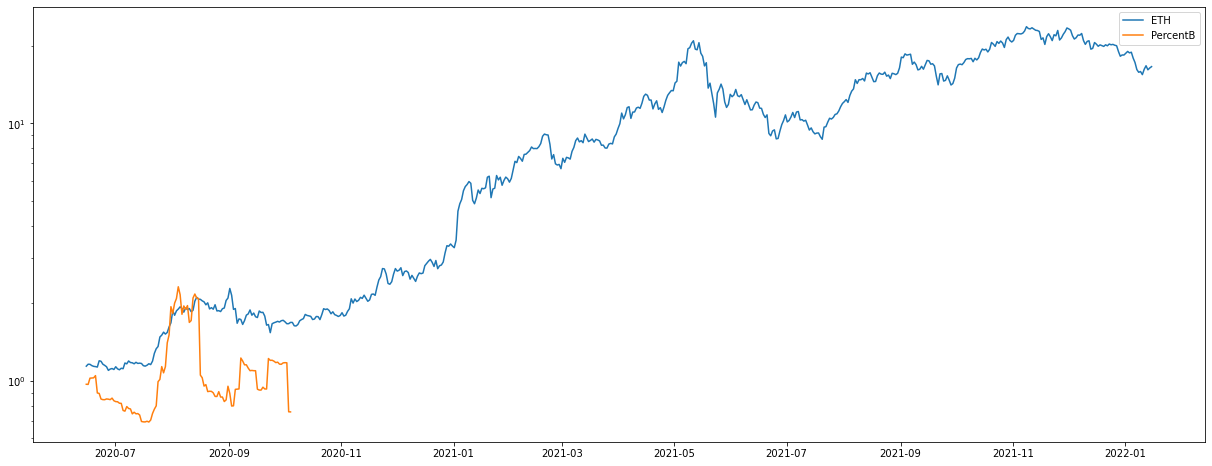

In [38]:
plt.figure(figsize=(21,8))
plt.yscale('log')
plt.plot(sample.index, sample.total_reward, label="ETH")
plt.plot(book.index, book.total_reward, label="PercentB")
plt.legend(loc='best')

plt.show()